
## Sensitivity Analysis on AlphaPEM using Sobol Method (N = 1024)

In this notebook, we study how different input parameters affect the behavior of the AlphaPEM model using Sobol sensitivity analysis. The model takes 13 input features, including operating conditions and physical parameters.

To do this, we:

* Generate Sobol samples using the SALib library with a base size of N = 1024.
* Run the AlphaPEM model on these samples to produce polarization curves.
* Compute the area under the polarization curve (AUC) in three regions of current density:

  * ***Activation;*** 0.0 to 0.4 A/cm²
  * ***Ohmic:*** 0.4 to 1.6 A/cm²
  * ***Mass transport:*** above 1.6 A/cm²
* Use these regional AUCs as the target outputs for sensitivity analysis.

If the cell voltage becomes negative during simulation, we treat it as zero from that point onward. This makes sure the AUC values reflect only physically meaningful parts of the curve.

This helps us understand which inputs matter the most in each current density region of the fuel cell's operation.


In [170]:
import os
import sys
import hashlib
import pickle

# For data science in general
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Sensitivity Analysis (SALib) 
from SALib.sample.sobol import sample as sobol_sample
from SALib.analyze import sobol

# Modeling
import xgboost as xgb

# Handling configurations 
from omegaconf import OmegaConf

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="SALib")

# Modules from our project
sys.path.append("../external/AlphaPEM")
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.validity.validity_criteria import validate_polarization_curves
from src.utils.auxiliar_func_FE import  plot_top_k_rankings_across_regions,select_top_features,plot_sobol_ranking

## Utils

In [ ]:
# --- Load parameter names from config ---
param_config = OmegaConf.load('../param_config.yaml')
parameter_names = list(param_config.keys())

# Add 'ifc' manually if you ever include it in plots
if 'ifc' not in parameter_names:
    parameter_names.append('ifc')

# --- Define consistent color map for all features ---
COLORS = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#612b20", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#A6761D", "#ffbb78", "#98df8a", "#393b79"
]
FEATURE_COLOR_MAP = {feat: COLORS[i % len(COLORS)] for i, feat in enumerate(parameter_names)}

In [3]:
def compute_region_auc(row, ifc_cols, ucell_cols, region_bounds, handle_negative="drop"):
    """
    Compute the discrete AUC for one region of the polarization curve.

    Parameters
    ----------
    row : pd.Series
        One row from the dataset.
    ifc_cols : list of str
        Columns containing current density values.
    ucell_cols : list of str
        Columns containing voltage values.
    region_bounds : tuple
        Tuple (lower_bound, upper_bound) for the region.
    handle_negative : str
        What to do with negative voltages:
        - 'drop': ignore (mask out) those points
        - 'zero': replace them with 0
        - 'keep': use as-is (default behavior)

    Returns
    -------
    float or np.nan
        Computed area under the curve for the given region.
    """
    import numpy as np

    ifcs = row[ifc_cols].values
    volts = row[ucell_cols].values
    mask_region = (ifcs >= region_bounds[0]) & (ifcs < region_bounds[1])

    if not np.any(mask_region):
        return np.nan

    region_ifcs = ifcs[mask_region]
    region_volts = volts[mask_region]

    if handle_negative == "drop":
        mask_valid = region_volts >= 0
        region_ifcs = region_ifcs[mask_valid]
        region_volts = region_volts[mask_valid]
    elif handle_negative == "zero":
        region_volts = np.maximum(region_volts, 0)

    if len(region_ifcs) < 2:
        return np.nan  # Need at least two points to integrate

    return np.trapezoid(region_volts, region_ifcs)

In [38]:
def add_confidence_intervals(df, index_col="S1", conf_col="S1_conf"):
    """
    Adds confidence interval bounds and a flag if 0 is inside the CI.

    Parameters:
        df (pd.DataFrame): Sobol index DataFrame with index and conf columns.
        index_col (str): Name of the Sobol index column (e.g. 'S1', 'ST', 'S2').
        conf_col (str): Name of the confidence column (e.g. 'S1_conf').

    Returns:
        pd.DataFrame: Updated DataFrame with CI bounds and zero flag.
    """
    df = df.copy()
    df["CI_lower"] = df[index_col] - df[conf_col]
    df["CI_upper"] = df[index_col] + df[conf_col]
    df["CI_contains_0"] = (df["CI_lower"] <= 0) & (df["CI_upper"] >= 0)
    return df

In [156]:
def run_sobol_analysis_for_region(Y, problem, region_name="activation"):
    """
    Run Sobol sensitivity analysis on a provided target vector Y.

    Parameters
    ----------
    Y : np.ndarray
        AUC targets for a region.
    problem : dict
        SALib problem definition.
    region_name : str
        Region label for display only.

    Returns
    -------
    Si, total_Si, first_Si, second_Si
    """
    Y = Y.to_numpy()
    
    # Run sobol
    print(f"[INFO] Running Sobol SA on the AUC of the '{region_name}' region.")
    Si = sobol.analyze(problem, Y, calc_second_order=True, print_to_console=False)
    total_Si, first_Si, second_Si = Si.to_df()

    # Convert to DataFrames
    total_Si, first_Si, second_Si = Si.to_df()

    # Add confidence interval processing
    first_Si = add_confidence_intervals(first_Si, "S1", "S1_conf")
    total_Si = add_confidence_intervals(total_Si, "ST", "ST_conf")
    second_Si = add_confidence_intervals(second_Si, "S2", "S2_conf")

    # --- Post-analysis summaries ---
    print("\n[SUMMARY] Sobol S1 (main effects):")
    s1_sum = round(first_Si["S1"].sum(), 4)
    s1_pos_sum = round(first_Si[first_Si["S1"] > 0]["S1"].sum(), 4)
    print("Sum of S1 indices:", s1_sum)
    print("Sum of S1 indices (setting negative indices to 0):", s1_pos_sum)
    if (first_Si["S1"] < 0).any():
        print("[WARNING] Some S1 indices are negative!")

    print("\n[SUMMARY] Sobol S2 (interaction effects):")
    s2_sum = second_Si["S2"].sum()
    s2_pos_mask = (second_Si["S2"] > 0) & (~second_Si["CI_contains_0"])
    s2_pos_sum = second_Si.loc[s2_pos_mask, "S2"].sum()
    print("Sum of second order:", round(s2_sum, 4))
    print("Sum of second order (only significant & > 0):", round(s2_pos_sum, 4))
    if (second_Si["S2"] < 0).any():
        print("[WARNING] Some S2 indices are negative!")

    print("\n[SUMMARY] Combined S1 + S2:")
    print("Sum of S1 and S2:", round(s1_sum + s2_sum,4))
    print("Sum of significant S1 + significant S2:", round(s1_pos_sum + s2_pos_sum, 4))

    return Si, total_Si, first_Si, second_Si

In [ ]:
def plot_sobol_index_convergence(sobol_results, index_type="ST", top_k=8, title=None, log_x=False, region=None, step=128, max_N=1024):
    """
    Plot how each feature's Sobol index (S1 or ST) changes as sample size N increases.

    Parameters
    ----------
    sobol_results : dict
        Output from run_sobol_convergence_analysis(). Maps N → dict with key 'sobol_df'.
    index_type : str
        Which index to plot: "S1" or "ST".
    top_k : int
        Number of top features to show based on the highest N.
    title : str or None
        Custom plot title.
    log_x : bool
        Use log scale on the x-axis.
    region : str or None
        Region name to include in the title.
    step : int
        Step size used during convergence (used for ticks).
    max_N : int
        Max base N used during convergence (used for ticks).
    """
    assert index_type in ["S1", "ST"], "index_type must be 'S1' or 'ST'"

    max_N_avail = max(sobol_results)
    df_max = sobol_results[max_N_avail]["sobol_df"]
    top_features = df_max.sort_values(index_type, ascending=False)["feature"].head(top_k).tolist()

    N_vals = sorted(sobol_results.keys())
    data = {f: [] for f in top_features}

    for N in N_vals:
        df = sobol_results[N]["sobol_df"].set_index("feature")
        for f in top_features:
            value = df.loc[f, index_type] if f in df.index else np.nan
            data[f].append(value)

    plt.figure(figsize=(10, 6))
    for f in top_features:
        plt.plot(N_vals, data[f], marker="o", label=f, color=FEATURE_COLOR_MAP.get(f, "#cccccc"))

    plt.ylabel(f"{index_type} Sobol Index")
    plt.xlabel("Sample Size N")

    # Force x-tick alignment
    full_N_ticks = list(range(step, max_N + 1, step))
    plt.xticks(full_N_ticks)

    plt.ylim(0, 1.05)
    if title is None:
        title = f"{index_type} Index Convergence for {region.capitalize()} Region" if region else f"{index_type} Index Convergence"
    plt.title(title)

    if log_x:
        plt.xscale("log")

    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend(loc="upper right", bbox_to_anchor=(1.18, 1.0))
    plt.tight_layout()
    plt.show()

In [161]:
def run_sobol_convergence_analysis(Y, problem, step=128, max_N=1024, index_type="S1"):
    """
    Run Sobol analysis for increasing sample sizes (powers of 2) to check convergence.

    Parameters
    ----------
    Y : np.ndarray
        Target values for sensitivity analysis.
    problem : dict
        SALib problem definition with parameter names and bounds.
    step : int
        Smallest N to consider (e.g. 128).
    max_N : int
        Largest N to consider (e.g. 1024).
    index_type : str
        "S1" or "ST"

    Returns
    -------
    sobol_convergence : dict
        Dictionary mapping N → {"sobol_df": DataFrame}
    """
    assert index_type in ["S1", "ST"], "index_type must be 'S1' or 'ST'"

    Y = Y.to_numpy()

    D = problem["num_vars"]
    samples_per_N = 2 * D + 2
    N_values = [2**i for i in range(int(np.log2(step)), int(np.log2(max_N)) + 1)]

    sobol_convergence = {}

    for N_i in N_values:
        end_idx = N_i * samples_per_N
        if end_idx > len(Y):
            print(f"[SKIP] Not enough samples for N={N_i}. Needed {end_idx}, but got {len(Y)}.")
            continue

        Y_subset = Y[:end_idx]

        try:
            Si = sobol.analyze(problem, Y_subset, calc_second_order=True, print_to_console=False)
            df_all = Si.to_df()
            df_si = df_all[0] if index_type == "ST" else df_all[1]
            df_si = df_si.copy()
            df_si["feature"] = problem["names"]
            sobol_convergence[N_i] = {"sobol_df": df_si}
        except Exception as e:
            print(f"[FAIL] Sobol failed at N={N_i}: {e}")

    return sobol_convergence

## Definition of problem + sampling

### Parameter ranges

In [6]:
# -------------------------------------
# Load parameter configuration
# -------------------------------------
config_path = '../param_config.yaml'
parameter_ranges = OmegaConf.load(config_path)
param_dict = dict(parameter_ranges)
print(f"Loaded the parameter ranges for {len(param_dict)} input features.")
print(param_dict)

# -------------------------------------
# Identify discrete parameters
# -------------------------------------
discrete_values_dict = {}
processed_bounds = {}

for param, values in param_dict.items():
    if len(values) > 2:
        # Discrete: Store list of valid values, use min/max as bounds
        print("Found discrete parameter:", param)
        discrete_values_dict[param] = values
        processed_bounds[param] = [min(values), max(values)]
    else:
        # Continuous: Use as-is
        processed_bounds[param] = values

Loaded the parameter ranges for 13 input features.
{'Tfc': [333, 363], 'Pa_des': [130000.0, 300000.0], 'Sc': [1.1, 3.0], 'Phi_c_des': [0.1, 0.7], 'epsilon_gdl': [0.55, 0.8], 'tau': [1.0, 4.0], 'epsilon_mc': [0.15, 0.4], 'epsilon_c': [0.15, 0.3], 'e': [3, 4, 5], 'Re': [5e-07, 5e-06], 'i0_c_ref': [0.001, 80], 'kappa_co': [15, 40], 'kappa_c': [0, 2.5]}
Found discrete parameter: e


In [8]:
# -------------------------------------
# Define SALib problem dictionary
# -------------------------------------
param_names = list(processed_bounds.keys())
bounds = [processed_bounds[name] for name in param_names]

problem = {
    'num_vars': len(param_names),
    'names': param_names,
    'bounds': bounds
}

print(problem)

{'num_vars': 13, 'names': ['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c'], 'bounds': [[333, 363], [130000.0, 300000.0], [1.1, 3.0], [0.1, 0.7], [0.55, 0.8], [1.0, 4.0], [0.15, 0.4], [0.15, 0.3], [3, 5], [5e-07, 5e-06], [0.001, 80], [15, 40], [0, 2.5]]}


### Generating Sobol samples

In this step, we create the input samples for sensitivity analysis using the Sobol method.
Sobol sequences are special sets of numbers that cover the space of possible inputs very evenly. This helps us explore the whole range of values for each input parameter without needing too many samples.

We use the `sobol_sample` function from SALib to generate a sample matrix with a base size of `N = 1024`. Each row is one input configuration that we will send to the AlphaPEM model. The result is stored in a DataFrame for easy processing later.


In [ ]:
# -------------------------------------
# Generate Sobol Samples
# -------------------------------------
N = 1024

X = sobol_sample(problem, N, calc_second_order=True, seed=42)

# Convert to DataFrame
df_param_values = pd.DataFrame(X, columns=param_names)

# Number of configurations
nconfigs_total = len(df_param_values)
print("Total number of configurations to be sampled:", nconfigs_total)

Total number of configurations to be sampled: 28672


### Cleaning and preparing the samples

Some of our input parameters are discrete (see <code>e</code>), meaning they can only take a few fixed values (like 3, 4, or 5). The Sobol generator gives continuous values, so here we round each sampled value to the nearest valid one for those parameters.

We also add a new input called `Pc_des`, which depends on another input:
`Pc_des = Pa_des - 20000`. This keeps the pressure difference between anode and cathode fixed.

Finally, we create a unique ID (`config_id`) for every row. This helps us track each input configuration later. We also store the row index to make merging easier.

In [11]:
# -------------------------------------
# Post-process discrete variables
# -------------------------------------
df_param_values_final = df_param_values.copy()

for param, valid_values in discrete_values_dict.items():
    df_param_values_final[param] = df_param_values_final[param].apply(
        lambda x: min(valid_values, key=lambda v: abs(v - x))
    )

# -------------------------------------
# Add dependent parameters
# -------------------------------------
df_param_values_final["Pc_des"] =  df_param_values_final["Pa_des"] - 20000

# -------------------------------------
# Adding unique identifier + index
# -------------------------------------
def row_hash(row):
    row_str = '|'.join([f"{x:.8g}" for x in row])
    return hashlib.sha256(row_str.encode()).hexdigest()

df_param_values_final["config_id"] = df_param_values_final[param_names].apply(row_hash, axis=1)
df_param_values_final["index"] = df_param_values_final.index

df_param_values_final = df_param_values_final[["index", "config_id"] + param_names].copy()
df_param_values_final.head()

,index,config_id,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c
0,0,cb1a18e56c5d5c41d39c4640e29bd3f2231631b7449018...,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265
1,1,af8ffd633f8f7c7b2d4071ee23fc3c03fe38ce822ce51f...,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265
2,2,2cb31c27fe89a331cdda00bb70a24401ebb4c7f0cc9179...,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265
3,3,55ffdc9133539a01473597aeab35970e09c730c6d41260...,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265
4,4,93da16dbbbb0c07635a27334f0ee3bbd0b75262fa47466...,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265


### Save the design matrix for sampling

In [ ]:
# df_param_values_final.to_pickle("../data/raw/nathaly_sobol_design_matrix.pkl")

## Loading simulation results

We now load the results from the AlphaPEM simulations. These results include the polarization curves: current density (`ifc`) and voltage (`Ucell`) for each configuration. We only keep these two columns and merge them with the original input samples using the `config_id` and `index` columns.

In [68]:
# Load simulated results 
results_path = "../data/raw/sampled_nathaly_sobol_design_matrix_forN1024.pkl"
df_sampled = pd.read_pickle(results_path)

# Keep only the columns we need 
df_sampled_reduced = df_sampled[["config_id", "index", "ifc", "Ucell"]].copy()

# Merge with input samples 
df_merged = pd.merge(
    df_param_values_final,
    df_sampled_reduced,
    on=["config_id", "index"],
    how="left"
)

print(f"Merged DataFrame has {len(df_merged)} rows.")

# Important: Organize the df in the same order from the design matrix
df_merged = df_merged.sort_values(by = "index")
df_merged.head()

Merged DataFrame has 28672 rows.


,index,config_id,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,ifc,Ucell
0,0,cb1a18e56c5d5c41d39c4640e29bd3f2231631b7449018...,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,"[0.0008208004935869315, 0.10081944072368557, 0...","[1.033670888626164, 0.9897184052886249, 0.9578..."
1,1,af8ffd633f8f7c7b2d4071ee23fc3c03fe38ce822ce51f...,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,"[0.0008137945541252691, 0.1008124229812766, 0....","[1.0214271389919458, 0.9758659124214419, 0.942..."
2,2,2cb31c27fe89a331cdda00bb70a24401ebb4c7f0cc9179...,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,"[0.0008164799253827624, 0.10081511290053446, 0...","[1.0367017913059788, 0.977547607286612, 0.9374..."
3,3,55ffdc9133539a01473597aeab35970e09c730c6d41260...,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,"[0.0008131434062072617, 0.10081177072603602, 0...","[1.0219945473178058, 0.9841541196384987, 0.956..."
4,4,93da16dbbbb0c07635a27334f0ee3bbd0b75262fa47466...,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,"[0.0008211807676086426, 0.10081982163259484, 0...","[1.0333646186064867, 0.989838191631308, 0.9582..."


In [69]:
print("There are", df_merged["Ucell"].isna().sum(), "missing polarization curves. AlphaPEM didn't run for those configs.")
df_merged.isna().sum()

There are 24 missing polarization curves. AlphaPEM didn't run for those configs.


index           0
config_id       0
Tfc             0
Pa_des          0
Sc              0
Phi_c_des       0
epsilon_gdl     0
tau             0
epsilon_mc      0
epsilon_c       0
e               0
Re              0
i0_c_ref        0
kappa_co        0
kappa_c         0
ifc            24
Ucell          24
dtype: int64

### Predicting missing polarization curves with XGBoost

Some of the configurations in the Sobol sample did not produce a valid polarization curve when run through the AlphaPEM model. For these cases, we use a trained XGBoost model to predict the missing `Ucell` values. We do this as follows:

1. Identify rows where `Ucell` is missing.
2. Use a known `ifc` vector as a reference.
3. Repeat the input parameters for each `ifc` point.
4. Combine the input features and current density as input to the model.
5. Predict the voltage (`Ucell`) and fill in the missing rows.
6. Merge the predicted results back into the full dataset.

In [75]:
with open("../results/sm/xgboost/xgb_nconfig_50000_no_neg_with_outerCV_final_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

# --- Split into valid and missing parts ---
df_missing = df_merged[df_merged["Ucell"].isna()].copy()
df_valid = df_merged[~df_merged["Ucell"].isna()].copy()

# --- Use a reference ifc vector from any valid row ---
valid_ifc_row = df_valid["ifc"].dropna().iloc[0]
ref_ifc = valid_ifc_row if isinstance(valid_ifc_row, list) else valid_ifc_row.tolist()

# --- Prepare and predict missing Ucell values ---
param_cols = list(df_param_values_final.columns.difference(["config_id", "index"]))

repeated_ifcs = []
repeated_ucells = []

for _, row in df_missing.iterrows():
    param_values = row[param_cols].values
    ifc_values = row["ifc"] if isinstance(row["ifc"], list) else ref_ifc
    n_points = len(ifc_values)
    
    # Repeat parameter values and reshape ifc
    repeated_params = np.tile(param_values, (n_points, 1))
    ifc_array = np.array(ifc_values).reshape(-1, 1).astype(np.float32)
    
    # Prepare input and predict
    X_pred = np.hstack([repeated_params, ifc_array])
    ucell_pred = xgb_model.predict(X_pred)

    repeated_ifcs.append(ifc_values)
    repeated_ucells.append(ucell_pred.tolist())

# --- Fill in predictions ---
df_missing["ifc"] = repeated_ifcs
df_missing["Ucell"] = repeated_ucells

# --- Combine back with valid data ---
df_merged = pd.concat([df_valid, df_missing], ignore_index=True)

print(f"Final merged DataFrame shape: {df_merged.shape}")

Final merged DataFrame shape: (28672, 18)


### Expanding current density and voltage columns

The `ifc` (current density) and `Ucell` (voltage) values are stored as lists in the dataset. To make them easier to work with (e.g. for plotting or computing region-based AUC), we expand each list into separate columns: `ifc_1`, `ifc_2`, ..., and `Ucell_1`, `Ucell_2`, ...


In [ ]:
# --- Expand 'ifc' list into individual columns ---
if "ifc" in df_merged.columns:
    ifc_expanded = pd.DataFrame(df_merged["ifc"].tolist(), index=df_merged.index)
    ifc_expanded.columns = [f"ifc_{i+1}" for i in range(ifc_expanded.shape[1])]
    df_merged = pd.concat([df_merged.drop(columns=["ifc"]), ifc_expanded], axis=1)

# --- Expand 'Ucell' list into individual columns ---
if "Ucell" in df_merged.columns:
    ucell_expanded = pd.DataFrame(df_merged["Ucell"].tolist(), index=df_merged.index)
    ucell_expanded.columns = [f"Ucell_{i+1}" for i in range(ucell_expanded.shape[1])]
    df_merged = pd.concat([df_merged.drop(columns=["Ucell"]), ucell_expanded], axis=1)

# VERY IMPORTANT: Organize in the expected order
df_merged = df_merged.sort_values(by = "index")

df_merged.head()

,index,config_id,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,...,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,Ucell_31
0,0,cb1a18e56c5d5c41d39c4640e29bd3f2231631b7449018...,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.739045,0.729589,0.720136,0.710694,0.701276,0.691868,0.682447,0.672998,0.663503,0.653945
1,1,af8ffd633f8f7c7b2d4071ee23fc3c03fe38ce822ce51f...,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.721294,0.714532,0.707312,0.699526,0.691418,0.682971,0.674209,0.665224,0.656077,0.646728
2,2,2cb31c27fe89a331cdda00bb70a24401ebb4c7f0cc9179...,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.671937,0.674898,0.678610,0.672720,0.664524,0.658328,0.651773,0.644676,0.636803,0.628512
3,3,55ffdc9133539a01473597aeab35970e09c730c6d41260...,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.726462,0.716607,0.706750,0.696888,0.686996,0.677051,0.667036,0.656930,0.646715,0.636370
4,4,93da16dbbbb0c07635a27334f0ee3bbd0b75262fa47466...,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,...,0.738852,0.729371,0.719911,0.710484,0.701083,0.691683,0.682266,0.672816,0.663316,0.653751


## Running Sobol SA on a specific region

We now compute the Sobol sensitivity indices for one region of the polarization curve.
The curve is split into three parts based on current density:

* **Activation region**: 0.0 – 0.4 A/cm²
* **Ohmic region**: 0.4 – 1.6 A/cm²
* **Mass transport region**: above 1.6 A/cm²

We calculate the area under the curve (AUC) for the selected region.
NOTE: If the voltage becomes negative, we set it to zero before computing the AUC.

Finally, we run the Sobol analysis using the AUC as the target and return the full set of sensitivity indices.


In [ ]:
ifc_cols = [col for col in df_merged.columns if col.startswith("ifc_")]
ucell_cols = [col for col in df_merged.columns if col.startswith("Ucell_")]

REGIONS = {
    "activation": (0.0, 0.4),
    "ohmic": (0.4, 1.6),
    "mass_transport": (1.6, np.inf),
}

for region_name in REGIONS.keys():
    region_bounds = REGIONS[region_name]   
    target_name = f"AUC_{region_name}"
    print(f"[INFO] Computing AUC target for region: {region_name}")
    df_merged[target_name] = df_merged.apply(
        compute_region_auc, axis=1, args=(ifc_cols, ucell_cols, region_bounds, "zero")
    )

# VERY IMPORTANT: Organize in the expected order
df_merged = df_merged.sort_values(by = "index")

[INFO] Computing AUC target for region: activation
[INFO] Computing AUC target for region: ohmic
[INFO] Computing AUC target for region: mass_transport


In [155]:
Si_activation, total_Si_activation, first_Si_activation, second_Si_activation = run_sobol_analysis_for_region(df_merged["AUC_activation"].to_numpy(), problem, region_name="activation")

[INFO] Running Sobol SA on the AUC of the 'activation' region.

[SUMMARY] Sobol S1 (main effects):
Sum of S1 indices: 0.9701
Sum of S1 indices (setting negative indices to 0): 0.9701

[SUMMARY] Sobol S2 (interaction effects):
Sum of second order: -0.166
Sum of second order (only significant & > 0): 0.0
[WARNING] Some S2 indices are negative!

[SUMMARY] Combined S1 + S2:
Sum of S1 and S2: 0.8041
Sum of significant S1 + significant S2: 0.9701


In [176]:
first_Si_activation.sort_values(by = "S1", ascending = False)

,S1,S1_conf,CI_lower,CI_upper,CI_contains_0
i0_c_ref,0.550017,0.097183,0.452835,0.647200,False
kappa_c,0.229282,0.044518,0.184764,0.273800,False
Tfc,0.084611,0.030626,0.053985,0.115237,False
Pa_des,0.059162,0.020421,0.038741,0.079582,False
kappa_co,0.024007,0.013737,0.010270,0.037745,False
Sc,0.007796,0.009096,-0.001300,0.016892,True
tau,0.004652,0.006479,-0.001827,0.011131,True
e,0.004250,0.012524,-0.008274,0.016773,True
Re,0.002390,0.004042,-0.001652,0.006433,True
epsilon_mc,0.002251,0.005650,-0.003399,0.007901,True


In [159]:
Si_ohmic, total_Si_ohmic, first_Si_ohmic, second_Si_ohmic = run_sobol_analysis_for_region(df_merged["AUC_ohmic"], problem, region_name="ohmic")

[INFO] Running Sobol SA on the AUC of the 'ohmic' region.

[SUMMARY] Sobol S1 (main effects):
Sum of S1 indices: 0.9303
Sum of S1 indices (setting negative indices to 0): 0.9322
[WARNING] Some S1 indices are negative!

[SUMMARY] Sobol S2 (interaction effects):
Sum of second order: -0.1791
Sum of second order (only significant & > 0): 0.0
[WARNING] Some S2 indices are negative!

[SUMMARY] Combined S1 + S2:
Sum of S1 and S2: 0.7512
Sum of significant S1 + significant S2: 0.9322


In [158]:
Si_mass, total_Si_mass, first_Si_mass, second_Si_mass = run_sobol_analysis_for_region(df_merged["AUC_mass_transport"], problem, region_name="mass_transport")

[INFO] Running Sobol SA on the AUC of the 'mass_transport' region.

[SUMMARY] Sobol S1 (main effects):
Sum of S1 indices: 0.8674
Sum of S1 indices (setting negative indices to 0): 0.8794
[WARNING] Some S1 indices are negative!

[SUMMARY] Sobol S2 (interaction effects):
Sum of second order: -0.1408
Sum of second order (only significant & > 0): 0.0
[WARNING] Some S2 indices are negative!

[SUMMARY] Combined S1 + S2:
Sum of S1 and S2: 0.7266
Sum of significant S1 + significant S2: 0.8794


### Convergence plots

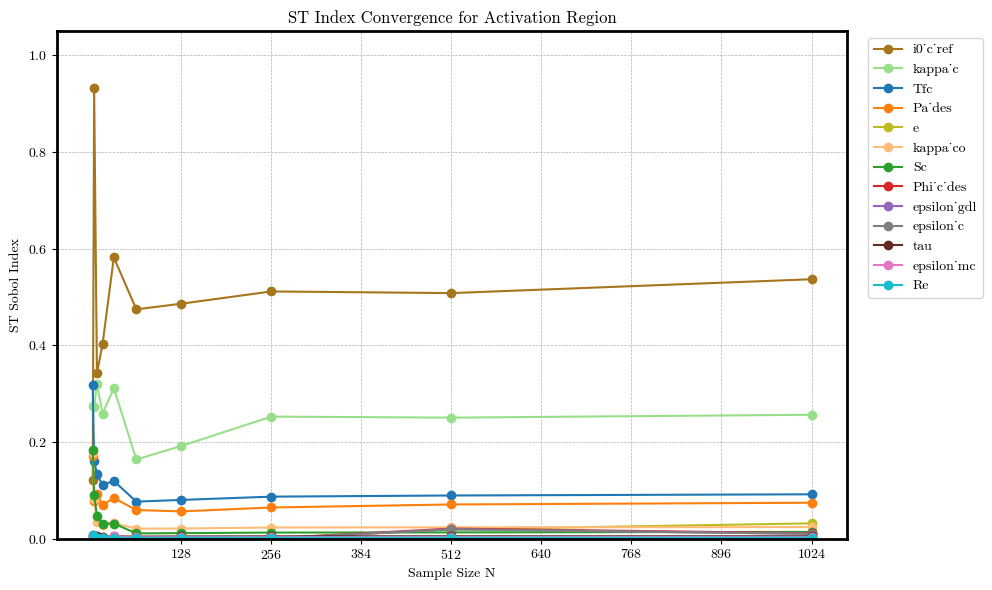

In [177]:
# Run convergence for activation region using ST index
sobol_convergence_activation = run_sobol_convergence_analysis(df_merged["AUC_activation"], problem, step=2, max_N=1024, index_type="ST")

# Plot convergence
plot_sobol_index_convergence(sobol_convergence_activation, index_type="ST", region="activation", top_k=13)

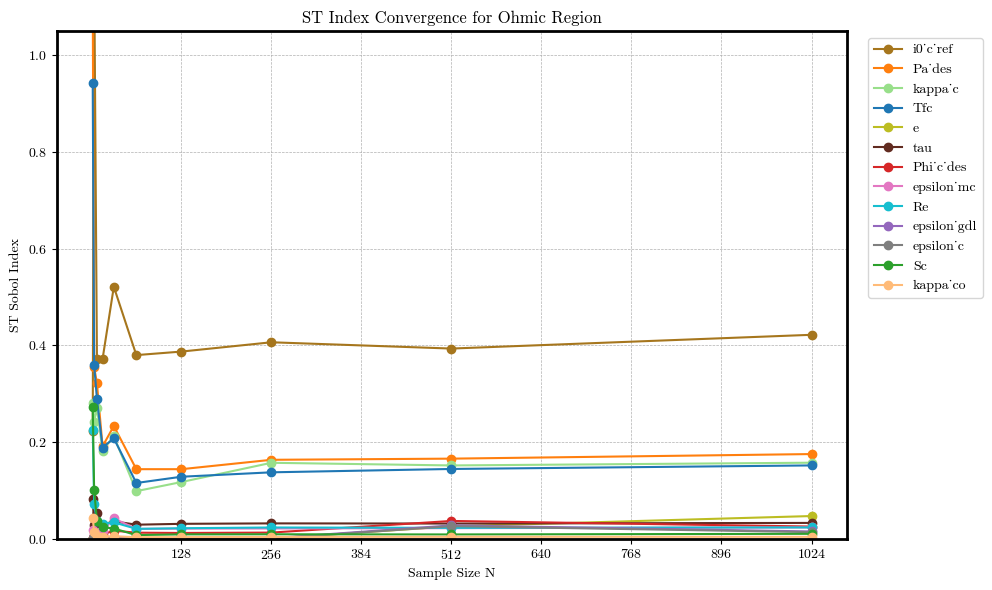

In [178]:
# Run convergence for activation region using ST index
sobol_convergence_ohmic = run_sobol_convergence_analysis(df_merged["AUC_ohmic"], problem, step=2, max_N=1024, index_type="ST")

# Plot convergence
plot_sobol_index_convergence(sobol_convergence_ohmic, index_type="ST", region="ohmic", top_k=13)

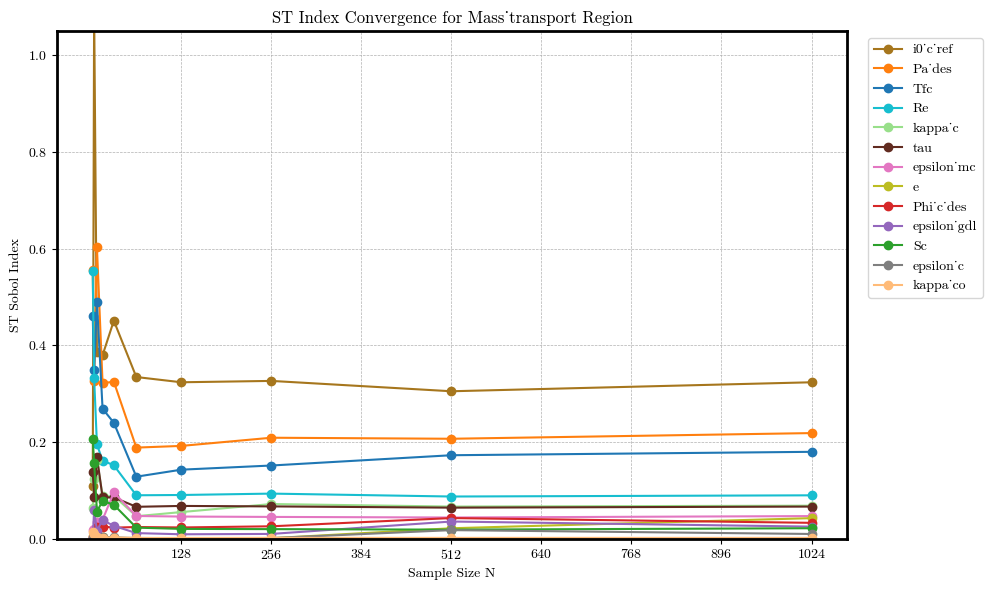

In [179]:
# Run convergence for activation region using ST index
sobol_convergence_mass = run_sobol_convergence_analysis(df_merged["AUC_mass_transport"], problem, step=2, max_N=1024, index_type="ST")

# Plot convergence
plot_sobol_index_convergence(sobol_convergence_mass, index_type="ST", region="mass_transport", top_k=13)

In [167]:
# Extract final ST DataFrame from each convergence result
rank_sources_st = {
    "activation": sobol_convergence_activation[max(sobol_convergence_activation.keys())]["sobol_df"],
    "ohmic": sobol_convergence_ohmic[max(sobol_convergence_ohmic.keys())]["sobol_df"],
    "mass_transport": sobol_convergence_mass[max(sobol_convergence_mass.keys())]["sobol_df"]
}

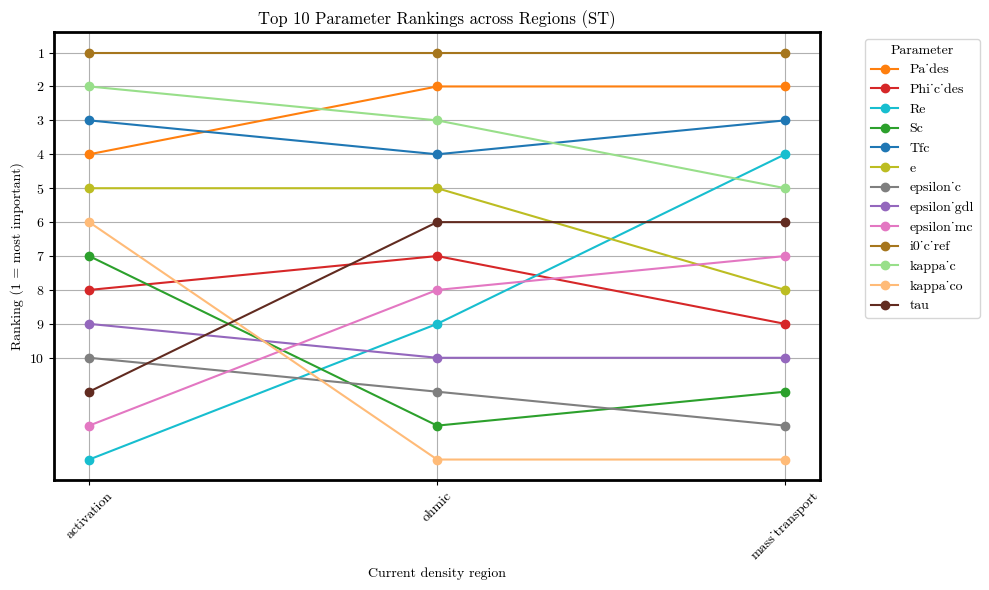

In [171]:
plot_top_k_rankings_across_regions(
    rank_sources=rank_sources_st,
    source_type="ST",        # Choose "S1", "ST", or "shap"
    top_k=10,                # How many top features to track
    figsize=(10, 6)
)